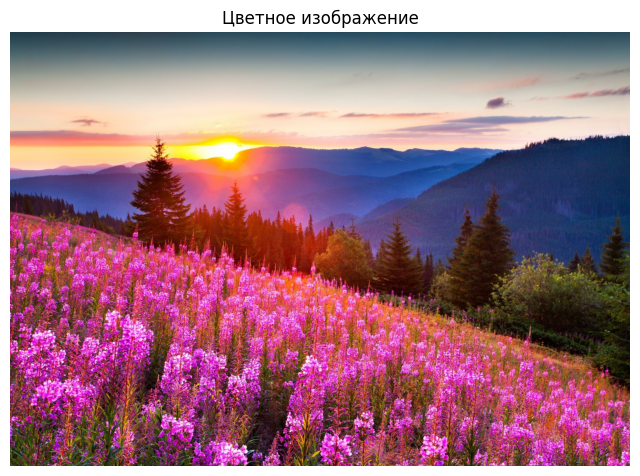

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с цветным изображением
image_color = cv2.imread('peizazhC.jpg')
image_color = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_color)
plt.title('Цветное изображение')
plt.axis('off')
plt.show()

Размерность: (1563, 2500)
Тип данных: uint8


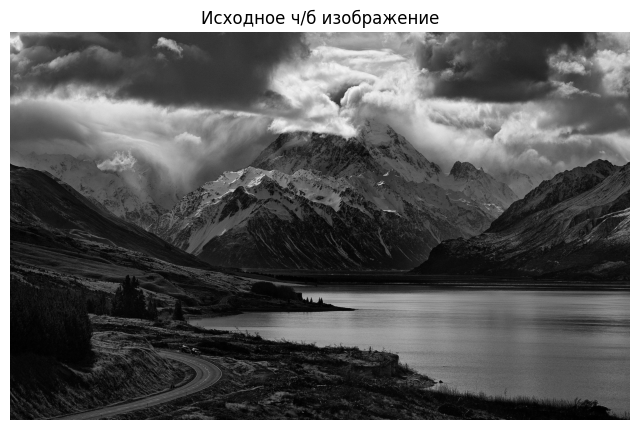

In [ ]:
# 1. Загрузка ч/б изображения
img_gray = cv2.imread('BWPeizazh.jpg', cv2.IMREAD_GRAYSCALE)

print(f"Размерность: {img_gray.shape}")
print(f"Тип данных: {img_gray.dtype}")

plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap='gray')
plt.title('Исходное ч/б изображение')
plt.axis('off')
plt.show()

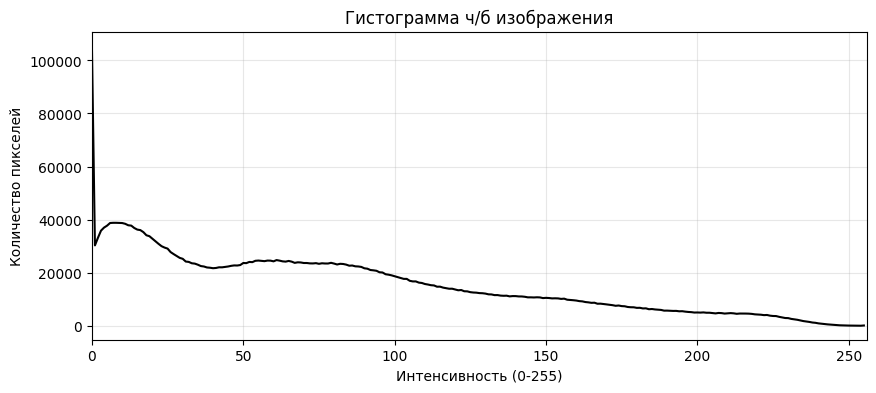

In [ ]:
# 2. Построение гистограммы
hist, bins = np.histogram(img_gray.flatten(), 256, [0, 256])

plt.figure(figsize=(10, 4))
plt.plot(hist, color='black')
plt.title('Гистограмма ч/б изображения')
plt.xlabel('Интенсивность (0-255)')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)
plt.xlim([0, 256])
plt.show()

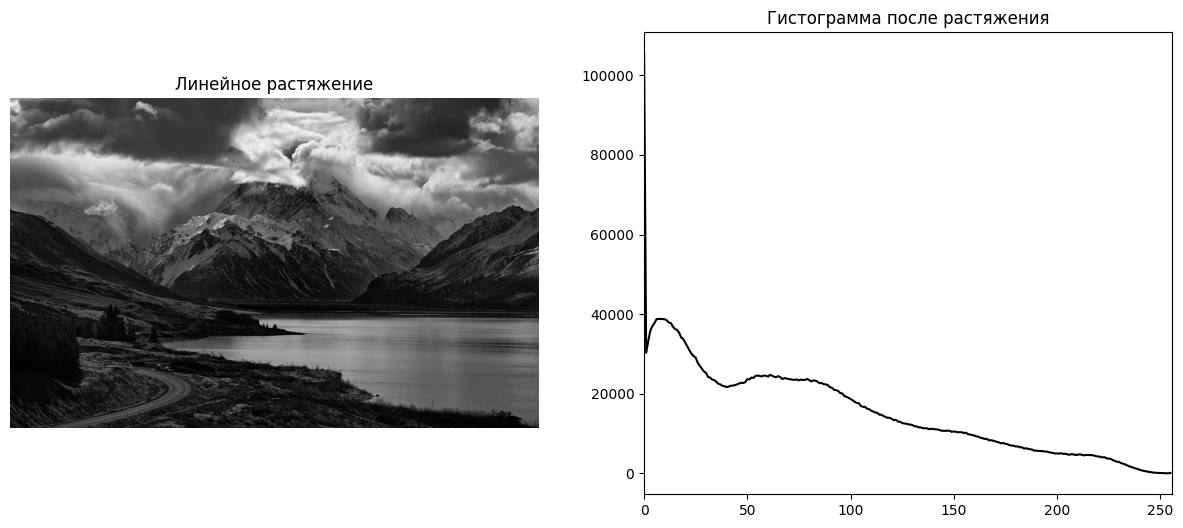

In [ ]:
# 3. Линейное растяжение гистограммы (автоконтраст)
def linear_stretch(image):
    i_min, i_max = np.min(image), np.max(image)
    if i_max == i_min:
        return image.copy()
    return (((image.astype(np.float32) - i_min) / (i_max - i_min)) * 255.0).astype(np.uint8)

img_stretched = linear_stretch(img_gray)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.imshow(img_stretched, cmap='gray')
ax1.set_title('Линейное растяжение')
ax1.axis('off')

hist_stretched, _ = np.histogram(img_stretched.flatten(), 256, [0, 256])
ax2.plot(hist_stretched, color='black')
ax2.set_title('Гистограмма после растяжения')
ax2.set_xlim([0, 256])
plt.show()

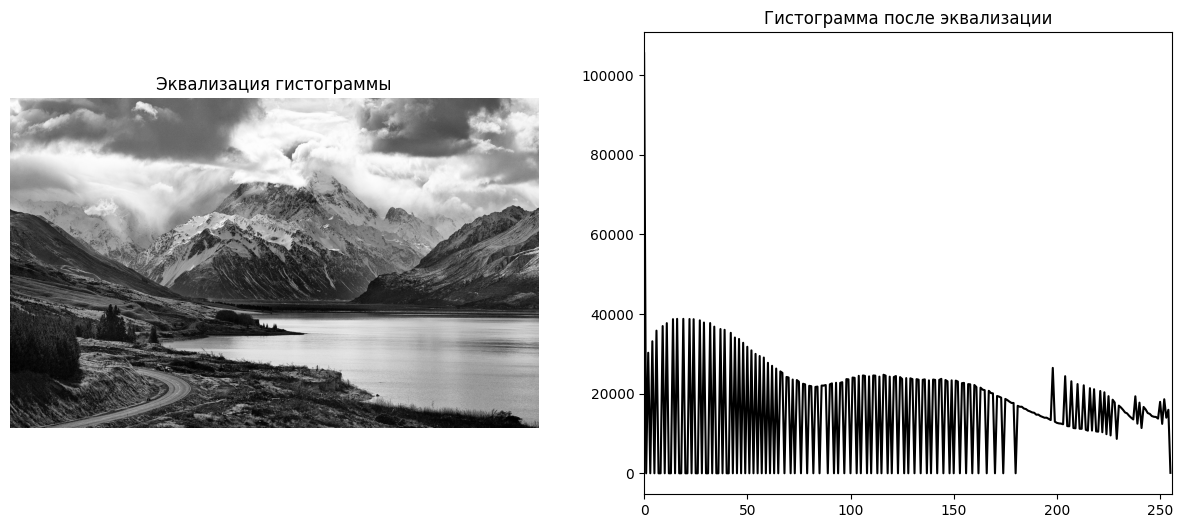

In [ ]:
# 4. Собственная реализация эквализации
def custom_equalization(image):
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf_final[image]

img_eq = custom_equalization(img_gray)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.imshow(img_eq, cmap='gray')
ax1.set_title('Эквализация гистограммы')
ax1.axis('off')

hist_eq, _ = np.histogram(img_eq.flatten(), 256, [0, 256])
ax2.plot(hist_eq, color='black')
ax2.set_title('Гистограмма после эквализации')
ax2.set_xlim([0, 256])
plt.show()

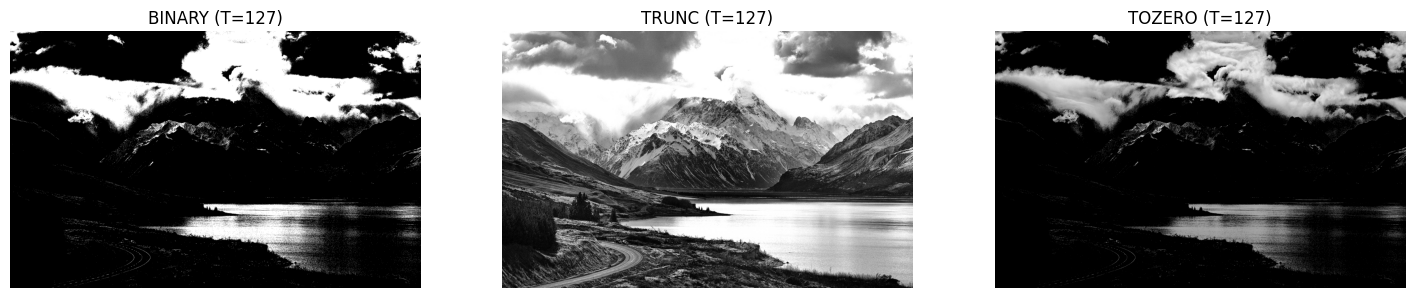

In [ ]:
# 5. Пороговая бинаризация
T = 127 # порог отсечения

img_bin = np.where(img_gray > T, 255, 0).astype(np.uint8)
img_trunc = np.where(img_gray > T, T, img_gray).astype(np.uint8)
img_tozero = np.where(img_gray > T, img_gray, 0).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_bin, cmap='gray')
axes[0].set_title(f'BINARY (T={T})')
axes[1].imshow(img_trunc, cmap='gray')
axes[1].set_title(f'TRUNC (T={T})')
axes[2].imshow(img_tozero, cmap='gray')
axes[2].set_title(f'TOZERO (T={T})')
for ax in axes: ax.axis('off')
plt.show()

In [ ]:
# 6. Оценка метрики MSE
def calc_mse(img1, img2):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    return np.mean(np.square(diff))

print(f"MSE (исходное vs линейное растяжение): {calc_mse(img_gray, img_stretched):.2f}")
print(f"MSE (исходное vs эквализация): {calc_mse(img_gray, img_eq):.2f}")

MSE (исходное vs линейное растяжение): 0.00
MSE (исходное vs эквализация): 2837.85
